### Part 2: Создание и редакторование изображений

 Сеть Stable Diffusion была обучена на наборе данных (несвязанных) изображений, включая много лошадей и зебр. Хотя человечество за последние несколько тысяч лет не затаивало дыхания в ожидании инструмента, который превращает лошадей в зебр, эта задача демонстрирует способность этих архитектур моделировать сложные реальные процессы с удаленным контролем. Хотя у них есть свои ограничения, есть намеки на то, что в ближайшем будущем мы не сможем отличить настоящее от подделки в прямом видеопотоке, что открывает целый ящик проблем, который мы сейчас аккуратно закроем. Игра с предобученной моделью позволяет нам увидеть, как создавать и запускать рабочий процесс инпейнтинга. Мы будем использовать «inpaint pipeline» из библиотеки diffusers, который упаковывает обученные компоненты и предоставляет простую функцию, принимающую исходное изображение, маску и текстовый запрос. Наша цель здесь — использовать его, а не реализовывать заново, поэтому мы сосредоточимся на вызове функции, а не на внутреннем устройстве

In [1]:
import sys
!{sys.executable} -m pip install diffusers transformers accelerate safetensors

In [2]:
%pip list

Package                   Version
------------------------- ------------
absl-py                   2.4.0
accelerate                1.13.0
addict                    2.4.0
annotated-doc             0.0.4
anyio                     4.12.1
argon2-cffi               25.1.0
argon2-cffi-bindings      25.1.0
arrow                     1.4.0
asttokens                 3.0.1
async-lru                 2.2.0
attrs                     25.4.0
babel                     2.18.0
beautifulsoup4            4.14.3
bleach                    6.3.0
certifi                   2026.2.25
cffi                      2.0.0
charset-normalizer        3.4.4
click                     8.3.1
colorama                  0.4.6
comm                      0.2.3
contourpy                 1.3.2
cycler                    0.12.1
debugpy                   1.8.20
decorator                 5.2.1
defusedxml                0.7.1
diffusers                 0.37.0
exceptiongroup            1.3.1
executing                 2.2.1
fastjsonschema   

In [3]:
!{sys.executable} -m pip install --upgrade transformers

In [4]:
%pip list


Package                   Version
------------------------- ------------
absl-py                   2.4.0
accelerate                1.13.0
addict                    2.4.0
annotated-doc             0.0.4
anyio                     4.12.1
argon2-cffi               25.1.0
argon2-cffi-bindings      25.1.0
arrow                     1.4.0
asttokens                 3.0.1
async-lru                 2.2.0
attrs                     25.4.0
babel                     2.18.0
beautifulsoup4            4.14.3
bleach                    6.3.0
certifi                   2026.2.25
cffi                      2.0.0
charset-normalizer        3.4.4
click                     8.3.1
colorama                  0.4.6
comm                      0.2.3
contourpy                 1.3.2
cycler                    0.12.1
debugpy                   1.8.20
decorator                 5.2.1
defusedxml                0.7.1
diffusers                 0.37.0
exceptiongroup            1.3.1
executing                 2.2.1
fastjsonschema   

In [2]:
from diffusers import StableDiffusionInpaintPipeline
import torch
import PIL.Image as Image

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"

Здесь мы создаем pipe, потоковую конвейерную систему диффузии для инпейнтинга. Конвейер объединяет все необходимые части для генерации — токенизатор и текстовый энкодер для текстового запроса, денойзер UNet, вариационный автоэнкодер (VAE), который сжимает изображение в компактное внутреннее («латентное») представление, а затем восстанавливает его, и планировщик — и переносит их на выбранное устройство:

In [4]:
pipe = StableDiffusionInpaintPipeline.from_pretrained(
    "sd2-community/stable-diffusion-2-inpainting",
    torch_dtype=torch.float16
).to(device)

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: C:\Users\Админ\.cache\huggingface\hub\models--sd2-community--stable-diffusion-2-inpainting\snapshots\5f74973cbb64c8568780732c17f43eb269d63a0d\text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [5]:
pipe

StableDiffusionInpaintPipeline {
  "_class_name": "StableDiffusionInpaintPipeline",
  "_diffusers_version": "0.37.0",
  "_name_or_path": "sd2-community/stable-diffusion-2-inpainting",
  "feature_extractor": [
    "transformers",
    "CLIPImageProcessor"
  ],
  "image_encoder": [
    null,
    null
  ],
  "requires_safety_checker": false,
  "safety_checker": [
    null,
    null
  ],
  "scheduler": [
    "diffusers",
    "PNDMScheduler"
  ],
  "text_encoder": [
    "transformers",
    "CLIPTextModel"
  ],
  "tokenizer": [
    "transformers",
    "CLIPTokenizer"
  ],
  "unet": [
    "diffusers",
    "UNet2DConditionModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}

In [6]:
img = Image.open(r"C:\Users\Админ\Desktop\py\DataScince\NN\learning\data\horse.jpg")

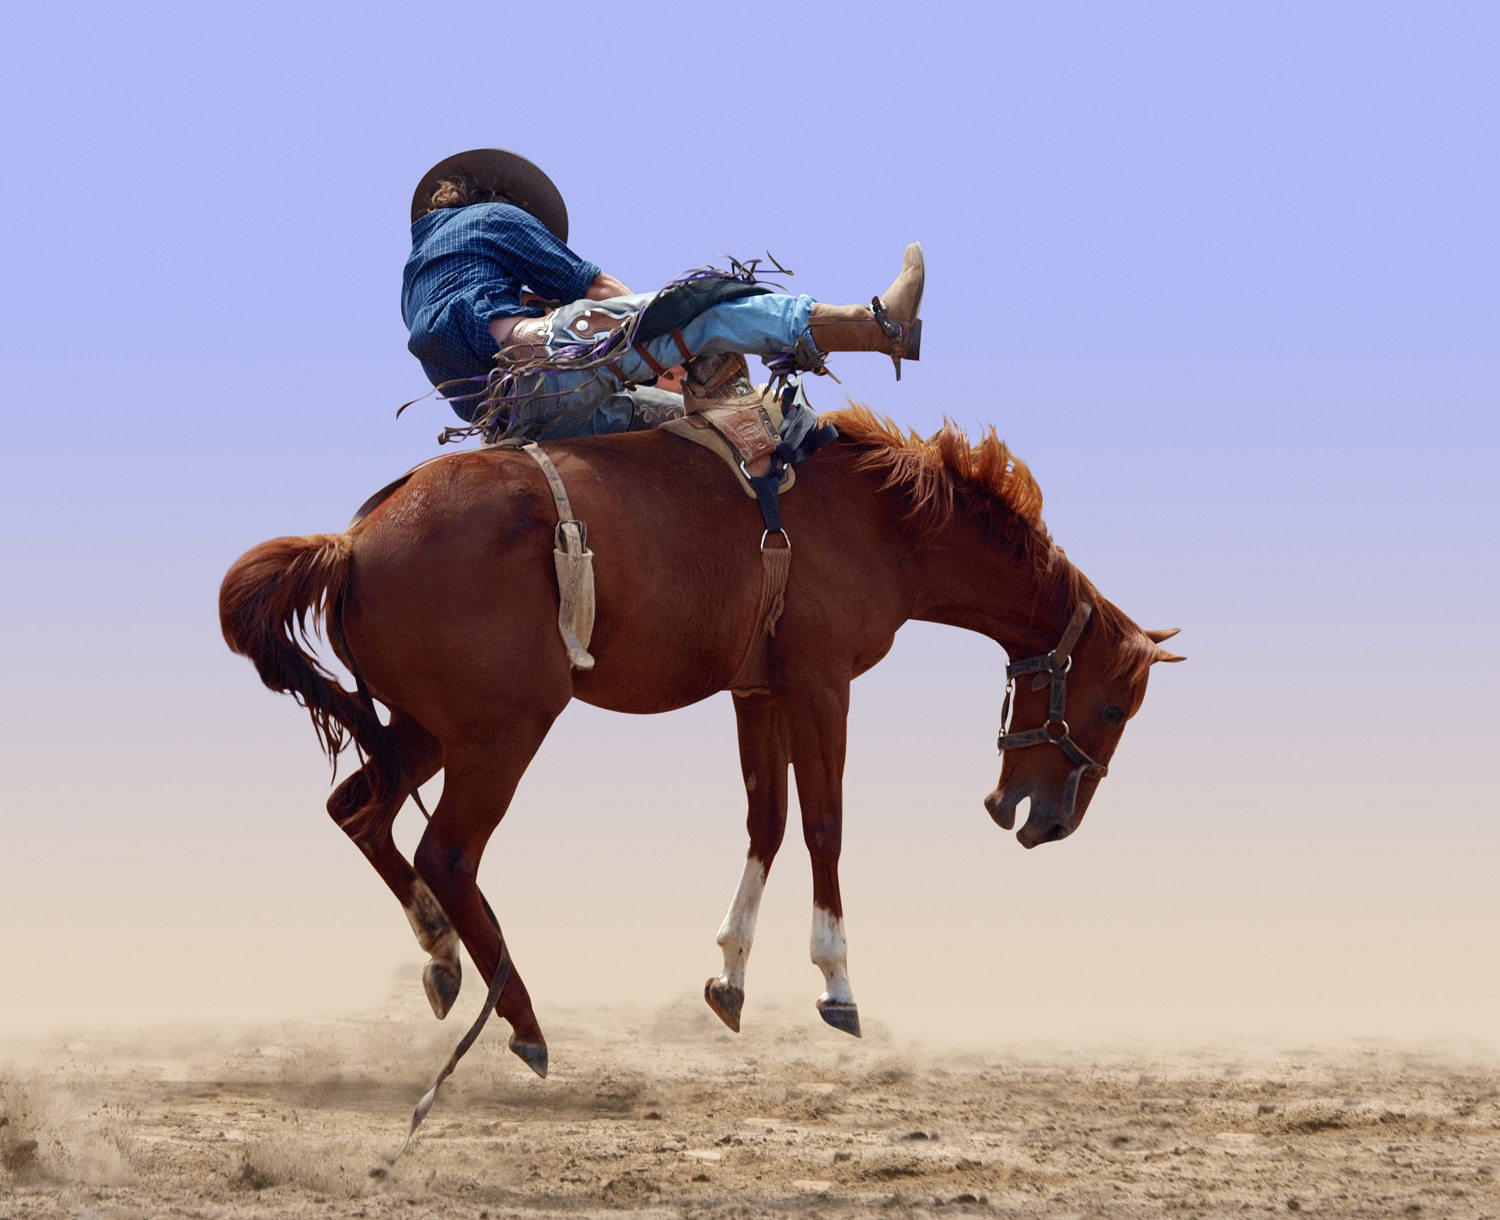

In [7]:
img

Хорошо, давайте передадим это вместе с нашей маской, которую мы создали через отдельный процесс. Мы пропустили генерацию изображения маски для краткости, но включили фрагмент кода в тот же файл. Теперь давайте передадим наш запрос, изображение и маску в конвейер:

In [50]:
mask_img = Image.open(r"C:\Users\Админ\Desktop\py\DataScince\NN\learning\data\horse_mask_refined.png")

In [51]:
prompt = (
    """convert the horse's coat into zebra stripes, keep the original anatomy,
keep the original pose and silhouette, do not modify shape,
only recolor the horse body into natural zebra pattern,
photorealistic, high detail, same lighting and background."""
)
negative = ( 
        """bent legs, warped limbs, altered pose, mutated body, changed anatomy,
extra stripes, unnatural patterns, blurry, low quality, extra limbs,
wrong colors, brown, grey, distorted edges, deformed silhouette,
text, watermark, logo"""
)

In [52]:
out = pipe(
    prompt=prompt,
    image=img,
    mask_image=mask_img,
    negative_prompt=negative,
    guidance_scale=7,  # Еще больше
    strength=0.4,  # Сильнее изменяем замаскированную область
    num_inference_steps=70,  # Больше шагов
    generator=torch.Generator(device).manual_seed(42)
)

  0%|          | 0/28 [00:00<?, ?it/s]

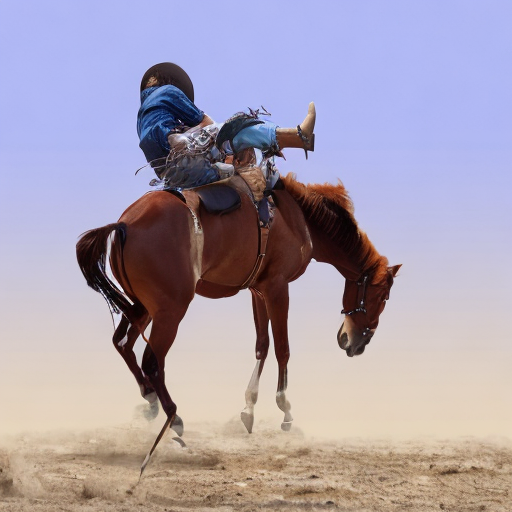

In [53]:
out_image = out.images[0]
out_image

In [15]:
#out_image.save(r"C:\Users\Админ\Desktop\py\DataScince\NN\learning\data\horse_out.png")

Вообщем смысл понятен, нужно подгонять параметры и промты!!!